In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
%matplotlib inline

In [69]:
df = pd.read_csv("default of credit card clients.csv", header=1)

In [70]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [71]:
df.shape

(30000, 25)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [73]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [74]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [75]:
df = df.rename(columns={'default payment next month': 'Y'})

In [76]:
df['Y'].value_counts(normalize=True)

Y
0    0.7788
1    0.2212
Name: proportion, dtype: float64

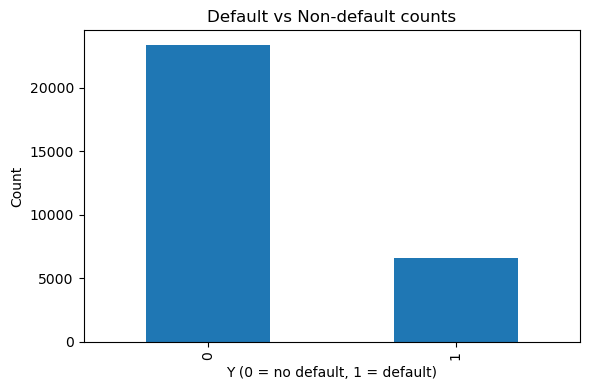

In [16]:
plt.figure(figsize=(6,4))
df['Y'].value_counts().plot(kind='bar')
plt.title("Default vs Non-default counts")
plt.xlabel("Y (0 = no default, 1 = default)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

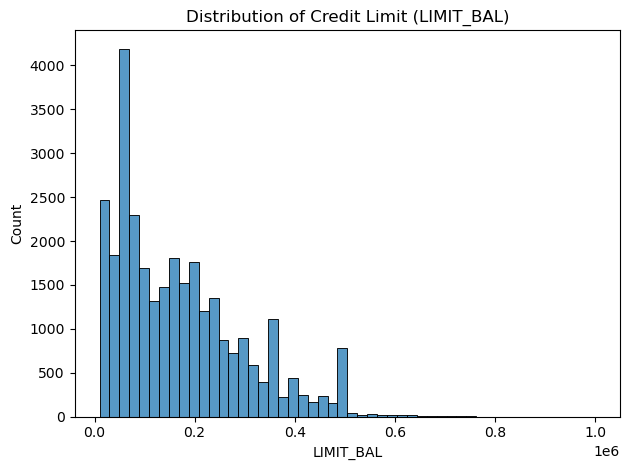

In [17]:
plt.figure()
sns.histplot(df['LIMIT_BAL'], bins=50)
plt.title("Distribution of Credit Limit (LIMIT_BAL)")
plt.tight_layout()
plt.show()

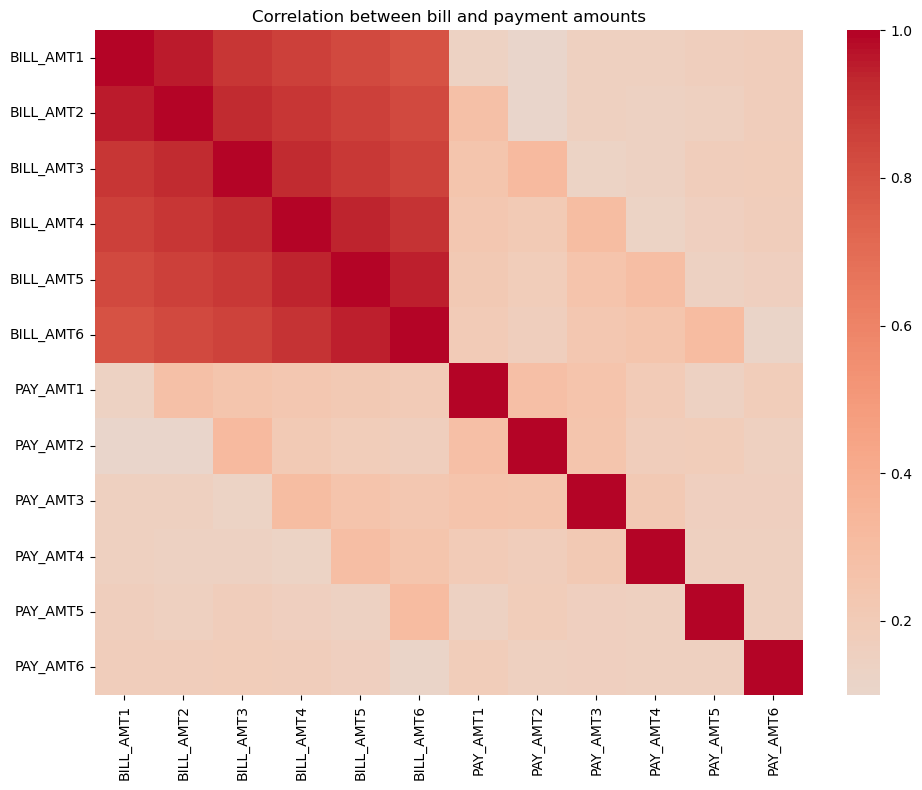

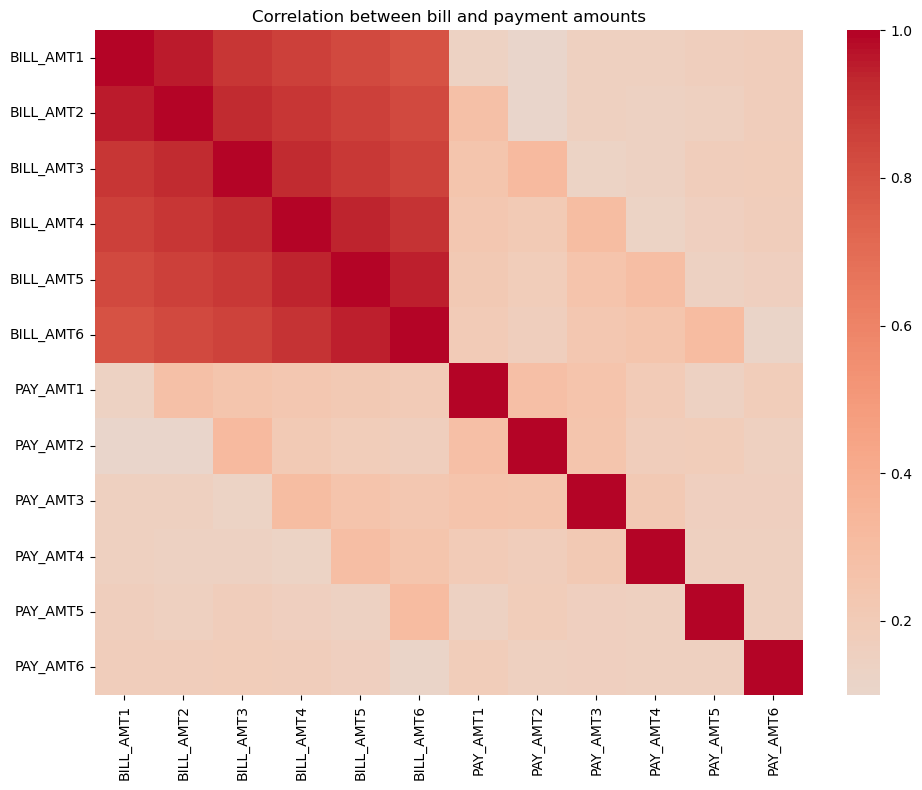

In [19]:
cols_money = [c for c in df.columns if 'BILL_AMT' in c or 'PAY_AMT' in c]
plt.figure(figsize=(10,8))
sns.heatmap(df[cols_money].corr(), cmap="coolwarm", center=0)
plt.title("Correlation between bill and payment amounts")
plt.tight_layout()
plt.show()

In [21]:
df_clust = df.drop(columns=['ID', 'Y'])

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

In [23]:
y = df['Y']

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

In [85]:
k_opt = 4 

kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

In [86]:
kmeans_final

KMeans(n_clusters=4, n_init=10, random_state=42)

In [87]:
agg_final = AgglomerativeClustering(
    n_clusters=k_opt,
    linkage='ward'
)

In [88]:
labels_agg = agg_final.fit_predict(X_scaled)

In [89]:
labels_agg

array([0, 0, 0, ..., 0, 1, 0])

In [90]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
db_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)

sil_agg = silhouette_score(X_scaled, labels_agg)
db_agg = davies_bouldin_score(X_scaled, labels_agg)

print(sil_kmeans, db_kmeans, sil_agg, db_agg)

0.1635291965995965 1.76004961681125 0.1318019009266833 2.1156850204757394


In [91]:
df_results = df.copy()
df_results['cluster_kmeans'] = labels_kmeans
df_results['cluster_agg'] = labels_agg

In [92]:
cluster_profiles = df_results.groupby('cluster_kmeans').agg({
    'LIMIT_BAL': 'mean',
    'AGE': 'mean',
    'SEX': 'mean',
    'EDUCATION': 'mean',
    'MARRIAGE': 'mean',
    'Y': ['mean', 'count'],
    'BILL_AMT1': 'mean',
    'PAY_AMT1': 'mean'
})

In [93]:
cluster_profiles

LIMIT_BAL        AGE       SEX EDUCATION  MARRIAGE  \
                         mean       mean      mean      mean      mean   
cluster_kmeans                                                           
0               288166.819127  37.083754  1.571726  1.804574  1.505495   
1               225442.732893  36.709316  1.649586  1.656083  1.488211   
2               118534.605868  34.370802  1.591375  1.968611  1.609049   
3                76808.149406  35.046520  1.551104  1.992530  1.536503   

                       Y             BILL_AMT1      PAY_AMT1  
                    mean  count           mean          mean  
cluster_kmeans                                                
0               0.180873   3367  204561.125631  16753.455895  
1               0.163471   9543    8920.151525   4727.399455  
2               0.185507  14145   45890.549381   4361.165712  
3               0.625806   2945   38606.380306   2273.774873

In [94]:
df_results.groupby('cluster_agg')['Y'].mean()

cluster_agg
0    0.284533
1    0.179773
2    0.171570
3    0.178000
Name: Y, dtype: float64

In [95]:
df_results.groupby('cluster_kmeans')['Y'].mean()

cluster_kmeans
0    0.180873
1    0.163471
2    0.185507
3    0.625806
Name: Y, dtype: float64